# 13 – Kennlinie, Carpet-Plot und Dauerlinie

Das Ternärdiagramm aus Notebook 12 hat eine Schwäche: P = c · V · ΔT ist ein Produkt, keine Summe. Die Normierung auf Summe 1 ist ein Kunstgriff und wirft das Niveau (kW, l/h) weg.

Hier drei Darstellungen, die ohne diese Normierung auskommen:

- **Kennlinie:** Volumenstrom über Leistung, doppeltlogarithmisch
- **Carpet-Plot:** Rücklauf und Durchfluss über Kalendertag und Tagesstunde
- **Dauerlinie:** Werte nach Größe sortiert, Überschreitungszeiten direkt ablesbar

Alle drei werden wie das Ternärdiagramm über alle Stationen exportiert.

Leitfragen:

- Welche Darstellung findet Stationen, die die anderen übersehen?
- Welche Kennzahl kann eine Veränderung nach der Begehung messen?

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import load_begehungen as lb
from src import stationsbilder as sb
from src import ternaer as tn

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

METER_DIR = ROOT / "data" / "processed" / "real_meters"
OUT_DIR = ROOT / "outputs" / "stationsbilder"

#zwei Gegenbeispiele wie in Notebook 12: 68956351 ist die Station mit
#dem ueber Jahre offenen Ventil, 69631918 laeuft unauffaellig
BEISPIEL_AUFFAELLIG = 68956351
BEISPIEL_UNAUFFAELLIG = 69631918

t0 = time.time()
serien = tn.lade_serien(METER_DIR)
roh = lb.begehung_dates_by_meter()
begehungsdatum = {int(k): (v[0] if isinstance(v, (list, tuple)) else v)
                  for k, v in roh.items()}
print(f"{len(serien)} Zaehlerreihen in {time.time() - t0:.0f} s")
print(f"Begehungsdatum fuer {len(begehungsdatum)} Zaehler")

100 Zaehlerreihen in 14 s
Begehungsdatum fuer 56 Zaehler


## 1 Die Brücke zum Ternärdiagramm

- Der Durchflussanteil aus Notebook 12 ist cov(log P, log V) / var(log P).
- Das ist gleichzeitig die Steigung der Regression von log V auf log P, also ein Kennlinienparameter.
- Beide Module müssen deshalb für jede Station dieselbe Zahl liefern. Das wird hier geprüft.

In [2]:
proben = []
for meter in sorted(serien)[:25]:
    tab = sb.punkttabelle(serien[meter], meter,
                          begehungsdatum=begehungsdatum.get(meter))
    if len(tab) < sb.MIN_PUNKTE:
        continue
    proben.append({
        "meter": meter,
        "steigung": sb.kennlinienfit(tab)["steigung"],
        "anteil_mod_flow": tn.modulationszerlegung(tab)["anteil_mod_flow"],
    })

probe = pd.DataFrame(proben)
probe["differenz"] = (probe["steigung"] - probe["anteil_mod_flow"]).abs()
print(f"{len(probe)} Stationen geprueft")
print(f"groesste Abweichung: {probe['differenz'].max():.2e}")
print(probe.head(6).round(6).to_string(index=False))

19 Stationen geprueft
groesste Abweichung: 0.00e+00
   meter  steigung  anteil_mod_flow  differenz
41566330  0.348359         0.348359        0.0
41628863  0.834983         0.834983        0.0
53198226  0.853954         0.853954        0.0
58177363  0.853542         0.853542        0.0
58177384  1.209108         1.209108        0.0
61620222  0.941248         0.941248        0.0


- Die Abweichung liegt bei Maschinengenauigkeit, beide Darstellungen zeigen dieselbe Größe.
- Die Kennlinie liefert zusätzlich: Niveau in kW und l/h, Spreizung als Isolinien, R² der Geraden.

## 2 Zwei Stationen im Bild

- Isolinien konstanter Spreizung sind im log-log-Bild Geraden mit Steigung 1. Die Spreizung braucht also keine eigene Achse.
- Die Farbe zeigt den Rücklauf. Die Performance wäre auf Stundenebene nur eine Umrechnung der Spreizung.

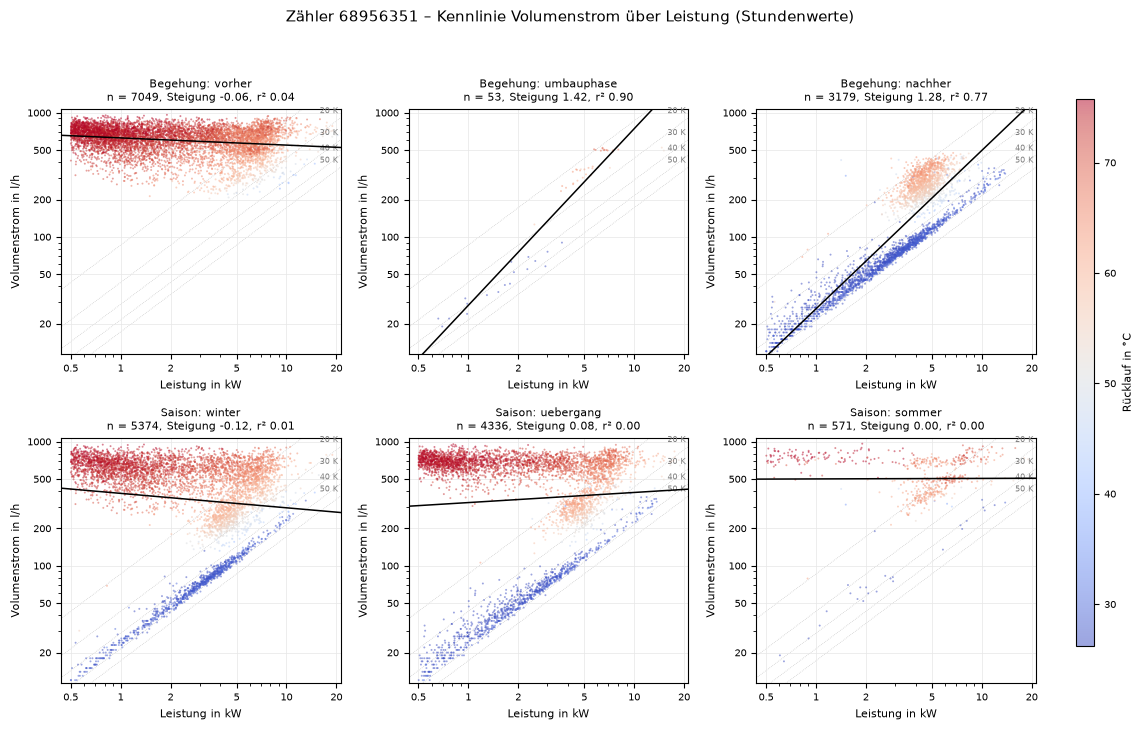

In [3]:
tabellen = {}
for meter in (BEISPIEL_AUFFAELLIG, BEISPIEL_UNAUFFAELLIG):
    for aufl in ("stunde", "tag"):
        tabellen[(meter, aufl)] = sb.punkttabelle(
            serien[meter], meter, aufloesung=aufl,
            begehungsdatum=begehungsdatum.get(meter))

fig = sb.kennliniengrafik(tabellen[(BEISPIEL_AUFFAELLIG, "stunde")],
                          BEISPIEL_AUFFAELLIG, "Stundenwerte")
plt.show()

**68956351, Schnitt an der Begehung (obere Zeile):**

- vorher: rote Wolke waagerecht bei rund 600 l/h, Rücklauf 65 bis 75 °C. Der Durchfluss steht fest, Steigung −0,06, R² 0,04. Es gibt keine Kennlinie.
- nachher: blaue Wolke auf einer Geraden mit Steigung 1,28, R² 0,77, zwischen den Isolinien 30 und 50 K
- Das ist die Station vor und nach der Reparatur des offenen Ventils.

**Saison (untere Zeile):** Winter und Übergang mischen beide Betriebsphasen. Die Steigung von −0,12 beschreibt keine von beiden.

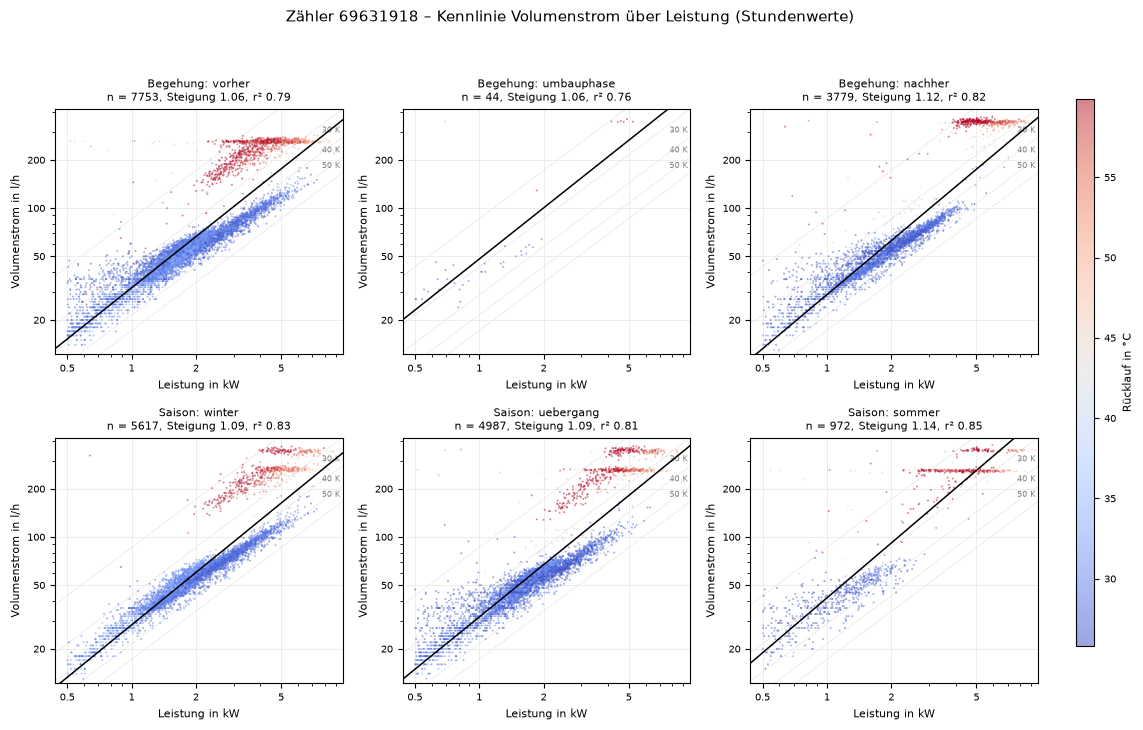

In [4]:
fig = sb.kennliniengrafik(tabellen[(BEISPIEL_UNAUFFAELLIG, "stunde")],
                          BEISPIEL_UNAUFFAELLIG, "Stundenwerte")
plt.show()

**69631918 (unauffällig):**

- Steigung in allen sechs Panels 1,06 bis 1,14, R² 0,76 bis 0,85
- Durchflussmedian 54 bis 59 l/h (kurze Umbauphase: 44 Punkte, 45,5 l/h)
- gleiches Regelverhalten über alle Jahreszeiten und über die Begehung hinweg

Auffällig: ein roter Nebenast bei 250 bis 300 l/h in Winter und Übergang. Dort läuft die Station zeitweise mit festem Durchfluss und warmem Rücklauf, also wie 68956351 vor der Reparatur. Im Ternärdiagramm war das nur eine zweite Wolke ohne Erklärung.

## 3 Vollexport

- alle drei Darstellungen über alle Stationen
- ausgewertet wird über die Kennzahlentabellen, die Bilder sind zur Kontrolle
- dauert ein paar Minuten

In [5]:
t0 = time.time()
kennzahlen = sb.exportiere(serien, OUT_DIR, begehungsdatum=begehungsdatum,
                           fortschritt=True)
print(f"\nExport in {time.time() - t0:.0f} s")

for name, tab in kennzahlen.items():
    print(f"{name}: {len(tab)} Zeilen, {tab['meter'].nunique()} Stationen")

for unter in ("kennlinie/stunde", "kennlinie/tag", "carpet", "dauerlinie"):
    pfad = OUT_DIR / unter
    n = len(list(pfad.glob("*.png"))) if pfad.exists() else 0
    print(f"PNG {unter}: {n}")

10/100 Stationen
20/100 Stationen
30/100 Stationen
40/100 Stationen
50/100 Stationen
60/100 Stationen
70/100 Stationen
80/100 Stationen
90/100 Stationen
100/100 Stationen

Export in 789 s
kennlinie: 1200 Zeilen, 100 Stationen
carpet: 100 Zeilen, 100 Stationen
dauerlinie: 1200 Zeilen, 100 Stationen
PNG kennlinie/stunde: 94
PNG kennlinie/tag: 98
PNG carpet: 100
PNG dauerlinie: 98


Stationen ohne Bild haben nach den Qualitätsfiltern aus `ternaer.py` keine verwertbaren Punkte. Sie stehen mit n = 0 in den Tabellen.

## 4 Was die Kennlinie über die Stationen sagt

Basis ist das Winterpanel auf Stundenebene, wie in Notebook 12.

In [6]:
kennlinie = kennzahlen["kennlinie"]
win = kennlinie[(kennlinie["schnitt"] == "saison")
                & (kennlinie["gruppe"] == "winter")
                & (kennlinie["aufloesung"] == "stunde")].copy()
win = win[win["steigung"].notna()]
print(f"{len(win)} Stationen mit belastbarem Winterfit")
print(win[["steigung", "r2", "residuum_sd", "flow_median_lh",
           "performance_median"]].describe().round(3).to_string())

klassen = [("flussgefuehrt (Steigung ueber 0,7)", 0.7, np.inf),
           ("gemischt (0,3 bis 0,7)", 0.3, 0.7),
           ("Durchfluss steht fest (unter 0,3)", -np.inf, 0.3)]
zeilen = []
for name, unten, oben in klassen:
    teil = win[(win["steigung"] > unten) & (win["steigung"] <= oben)]
    zeilen.append({"klasse": name, "n": len(teil),
                   "r2_median": teil["r2"].median(),
                   "flow_median_lh": teil["flow_median_lh"].median(),
                   "performance_median": teil["performance_median"].median()})
print()
print(pd.DataFrame(zeilen).round(3).to_string(index=False))

94 Stationen mit belastbarem Winterfit
       steigung      r2  residuum_sd  flow_median_lh  performance_median
count    94.000  94.000       94.000          94.000              94.000
mean      0.801   0.626        0.319         759.053              29.663
std       0.330   0.282        0.170        2467.036              10.473
min      -0.116   0.000        0.034          34.000               7.094
25%       0.651   0.433        0.212          94.250              22.708
50%       0.895   0.730        0.270         164.000              30.296
75%       1.044   0.859        0.402         270.750              36.373
max       1.385   0.938        0.890       15990.000              47.450

                            klasse  n  r2_median  flow_median_lh  performance_median
flussgefuehrt (Steigung ueber 0,7) 68      0.789           132.0              34.367
            gemischt (0,3 bis 0,7) 17      0.427           164.0              23.376
 Durchfluss steht fest (unter 0,3)  9      0.012

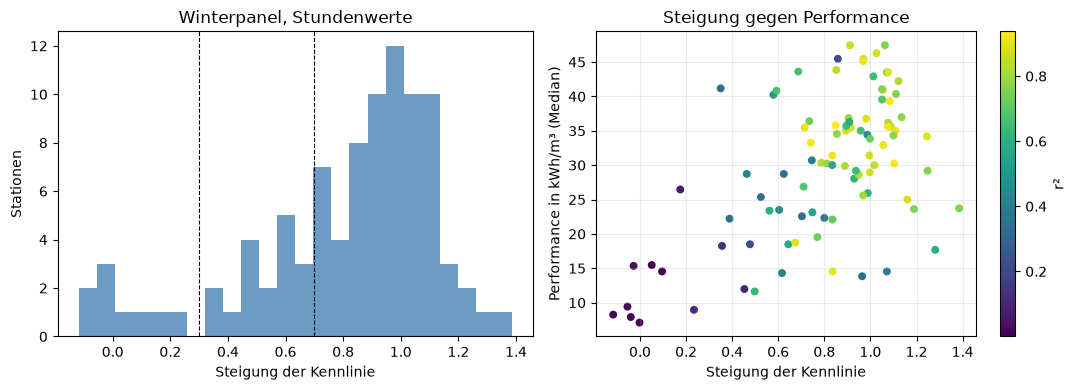

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(win["steigung"], bins=24, color="steelblue", alpha=0.8)
axes[0].axvline(0.3, color="black", lw=0.8, ls="--")
axes[0].axvline(0.7, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Steigung der Kennlinie")
axes[0].set_ylabel("Stationen")
axes[0].set_title("Winterpanel, Stundenwerte")

punkte = axes[1].scatter(win["steigung"], win["performance_median"],
                         c=win["r2"], cmap="viridis", s=22)
axes[1].set_xlabel("Steigung der Kennlinie")
axes[1].set_ylabel("Performance in kWh/m³ (Median)")
axes[1].set_title("Steigung gegen Performance")
axes[1].grid(alpha=0.25)
fig.colorbar(punkte, ax=axes[1], label="r²")
fig.tight_layout()
plt.show()

In [8]:
print("Spearman gegen die Performance, Winterpanel Stunde")
for spalte in ("steigung", "r2", "residuum_sd", "flow_median_lh",
               "dt_median_k"):
    teil = win[[spalte, "performance_median"]].dropna()
    rho, p = stats.spearmanr(teil[spalte], teil["performance_median"])
    print(f"{spalte:>16}: rho {rho:+.3f}  p {p:.2e}  n {len(teil)}")

teil = win[["steigung", "r2"]].dropna()
rho, p = stats.spearmanr(teil["steigung"], teil["r2"])
print(f"\nSteigung gegen r2: rho {rho:+.3f}, p {p:.2e}")

Spearman gegen die Performance, Winterpanel Stunde
        steigung: rho +0.476  p 1.22e-06  n 94
              r2: rho +0.537  p 2.41e-08  n 94
     residuum_sd: rho -0.294  p 3.99e-03  n 94
  flow_median_lh: rho -0.687  p 2.21e-14  n 94
     dt_median_k: rho +1.000  p 0.00e+00  n 94

Steigung gegen r2: rho +0.617, p 3.65e-11


**Vorzeichen aus Notebook 12 geklärt:**

- Steigung gegen Performance: ρ = +0,476 (derselbe Zusammenhang wie −0,48 in Notebook 12, nur gespiegelt)
- Steigung nahe 1: Station regelt über den Durchfluss. Das sind die effizienten.
- Steigung nahe 0: der Durchfluss steht fest. Das ist keine „Spreizungsmodulation".
- Die neun Stationen dieser Klasse haben im Median R² 0,01 und 9,4 kWh/m³, die flussgeführten 34,4 kWh/m³ (Faktor 3,7).

**Vorsicht bei Korrelationen mit der Performance:**

- `dt_median_k` gegen Performance ergibt ρ = +1,000. Das ist Definition: auf Stundenebene ist Performance = 1,163 · ΔT.
- Alles, was an der Spreizung hängt, korreliert deshalb automatisch mit, auch der Durchflussmedian (−0,687).
- Aussagekräftig wird es erst gegen eine unabhängige Größe wie die Begehung (Abschnitt 6).

**R²:** hängt eng an der Steigung (ρ = +0,62). Als eigenes Merkmal ist die Residuenstreuung besser geeignet.

## 5 Der Carpet-Plot

Was der Carpet zeigt und die Punktwolken nicht:

- Stillstand (weiße Fläche)
- Zeitprogramme
- Nachtabsenkung

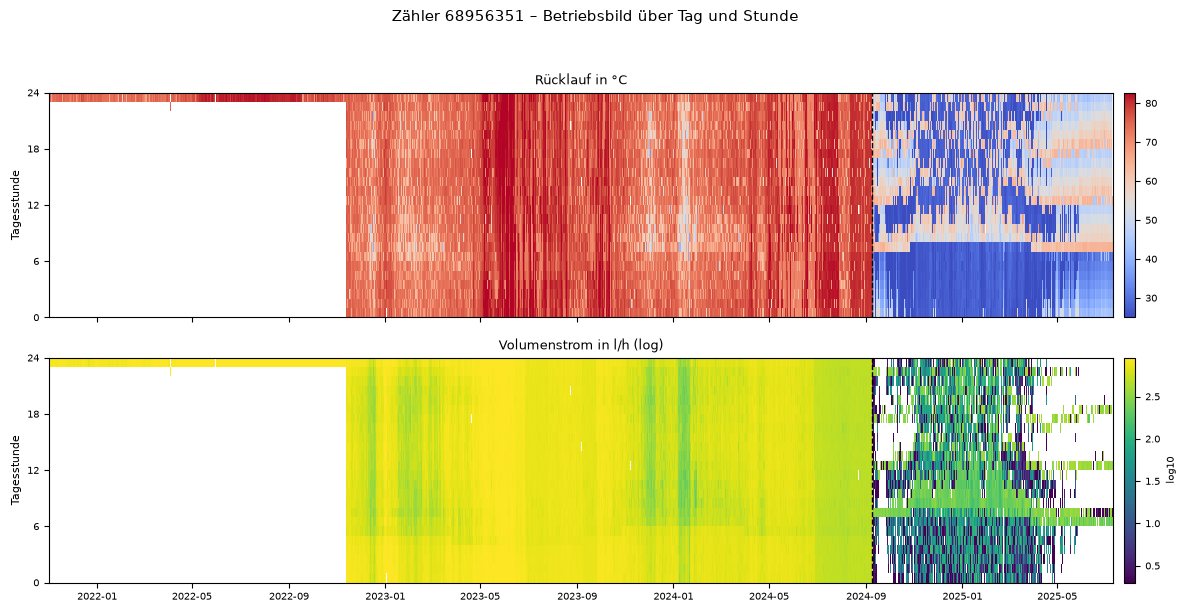

In [9]:
fig = sb.carpetgrafik(serien[BEISPIEL_AUFFAELLIG], BEISPIEL_AUFFAELLIG,
                      begehungsdatum=begehungsdatum.get(BEISPIEL_AUFFAELLIG))
plt.show()

- Der Regimewechsel ist eine senkrechte Kante genau am Begehungstermin.
- Links davon: rund um die Uhr rot und gelb, Rücklauf über 65 °C, hoher Durchfluss, kein Tagesgang.
- Rechts davon: blau, klares Zeitmuster, weiße Flächen mit Stillstand.
- Die weiße Fläche ganz links ist kein Stillstand: vor November 2022 liefert der Zähler nur einen Wert pro Tag.

In [10]:
carpet = kennzahlen["carpet"]
print(carpet[["nachtabsenkung_k", "sommer_nacht_anteil", "stillstand_anteil",
              "rt_ueber_schwelle_anteil"]].describe().round(3).to_string())

zus = carpet.merge(win[["meter", "performance_median", "steigung", "r2"]],
                   on="meter", how="inner")
print(f"\nmit Winterfit verknuepft: {len(zus)} Stationen")
for spalte in ("nachtabsenkung_k", "sommer_nacht_anteil",
               "stillstand_anteil", "rt_ueber_schwelle_anteil"):
    t = zus[[spalte, "performance_median"]].dropna()
    rho, p = stats.spearmanr(t[spalte], t["performance_median"])
    print(f"{spalte:>26}: rho {rho:+.3f}  p {p:.2e}  n {len(t)}")

print("\nZehn Stationen mit dem laengsten warmen Ruecklauf")
print(carpet.nlargest(10, "rt_ueber_schwelle_anteil")[
    ["meter", "rt_ueber_schwelle_anteil", "nachtabsenkung_k",
     "sommer_nacht_anteil", "stillstand_anteil"]].round(3).to_string(
         index=False))

       nachtabsenkung_k  sommer_nacht_anteil  stillstand_anteil  rt_ueber_schwelle_anteil
count           100.000              100.000            100.000                   100.000
mean              3.786                0.267              0.245                     0.427
std               6.927                0.222              0.169                     0.324
min              -8.800                0.000              0.000                     0.000
25%              -0.500                0.092              0.111                     0.155
50%               1.650                0.194              0.225                     0.328
75%               7.200                0.455              0.375                     0.704
max              28.900                0.878              0.732                     1.000

mit Winterfit verknuepft: 94 Stationen
          nachtabsenkung_k: rho +0.220  p 3.31e-02  n 94
       sommer_nacht_anteil: rho -0.348  p 5.86e-04  n 94
         stillstand_anteil: rho +0.2

**Nachtabsenkung:**

- streut von −8,8 bis +28,9 K, Median 1,65 K. Die Hälfte der Stationen fährt nachts praktisch wie tagsüber.
- hängt nur schwach mit der Performance zusammen (ρ = +0,22, p = 0,03), ist dafür unabhängig von der Spreizung

**Sommernächte mit Durchfluss:**

- ρ = −0,35 gegen die Performance (p = 0,0006). Wer im Juli nachts Wasser zieht, hat Verluste ohne Heizlast.
- Spitzenwert 0,88 bei 86792512. Das ist laut Zuordnung ein BHKW und soll durchlaufen.

**Längster warmer Rücklauf:** In den Top 10 stehen 66761022, 86792512 und 58202380, also das Ausreißer-Trio aus Notebook 01. Bestätigt über einen anderen Rechenweg.

## 6 Die Dauerlinie und die Begehungswirkung

Die Dauerlinie sortiert die Werte absteigend über dem Zeitanteil. Man liest direkt ab, in wie viel Prozent der Zeit ein Wert überschritten wird.

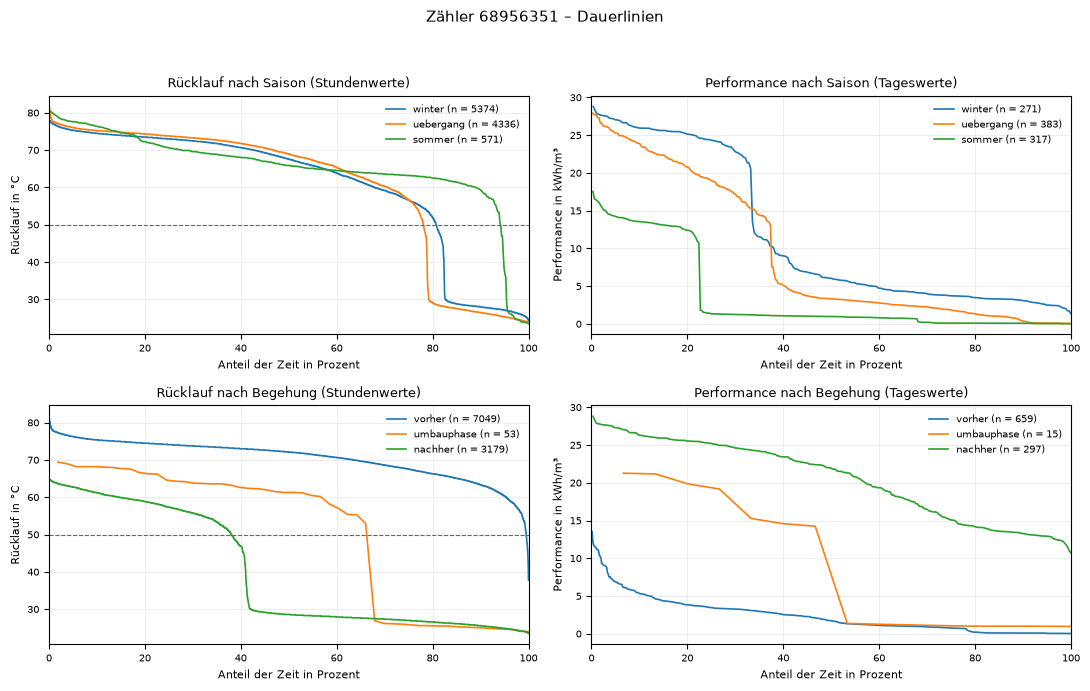

In [11]:
fig = sb.dauerliniengrafik(tabellen[(BEISPIEL_AUFFAELLIG, "stunde")],
                           tabellen[(BEISPIEL_AUFFAELLIG, "tag")],
                           BEISPIEL_AUFFAELLIG)
plt.show()

- Vor der Begehung liegt der Rücklauf fast die ganze Zeit über 50 °C, danach nur noch in gut 40 % der Zeit.

Jetzt für alle Stationen: Lässt sich die Wirkung der Begehungen messen? In Notebook 12 kam beim Modulationsanteil nichts raus (p = 0,51). Getestet wird gepaart über alle Stationen mit Werten vor und nach der Begehung.

In [12]:
dauer = kennzahlen["dauerlinie"]
for groesse, feld, richtung in (("rt_c", "ueber_schwelle_anteil", "kleiner"),
                                ("performance", "p50", "groesser")):
    teil = dauer[(dauer["schnitt"] == "begehung")
                 & (dauer["groesse"] == groesse)]
    breit = teil.pivot_table(index="meter", columns="gruppe", values=feld)
    breit = breit.dropna(subset=["vorher", "nachher"])
    diff = breit["nachher"] - breit["vorher"]
    besser = int((diff < 0).sum()) if richtung == "kleiner" \
        else int((diff > 0).sum())
    w, p = stats.wilcoxon(breit["nachher"], breit["vorher"])
    print(f"{groesse}/{feld}: n = {len(breit)}, Median der Differenz "
          f"{diff.median():+.4f}, besser bei {besser}, Wilcoxon p {p:.4f}")

beg = kennlinie[(kennlinie["schnitt"] == "begehung")
                & (kennlinie["aufloesung"] == "stunde")]
for feld in ("steigung", "r2"):
    breit = beg.pivot_table(index="meter", columns="gruppe", values=feld)
    breit = breit.dropna(subset=["vorher", "nachher"])
    diff = breit["nachher"] - breit["vorher"]
    w, p = stats.wilcoxon(breit["nachher"], breit["vorher"])
    print(f"{feld}: n = {len(breit)}, Median der Differenz "
          f"{diff.median():+.3f}, Wilcoxon p {p:.4f}, "
          f"deutlich hoch {int((diff > 0.2).sum())}, "
          f"deutlich runter {int((diff < -0.2).sum())}")

rt_c/ueber_schwelle_anteil: n = 44, Median der Differenz -0.0201, besser bei 26, Wilcoxon p 0.0477
performance/p50: n = 42, Median der Differenz +1.3146, besser bei 28, Wilcoxon p 0.0043
steigung: n = 41, Median der Differenz -0.023, Wilcoxon p 0.5044, deutlich hoch 5, deutlich runter 5
r2: n = 41, Median der Differenz -0.018, Wilcoxon p 0.6628, deutlich hoch 3, deutlich runter 4


In [13]:
breit = beg.pivot_table(index="meter", columns="gruppe", values="steigung")
breit = breit.dropna(subset=["vorher", "nachher"])
breit["differenz"] = breit["nachher"] - breit["vorher"]
print("Groesste Veraenderung der Kennliniensteigung um die Begehung")
print(breit.reindex(breit["differenz"].abs().sort_values(
    ascending=False).index).head(8)[
        ["vorher", "nachher", "differenz"]].round(3).to_string())

Groesste Veraenderung der Kennliniensteigung um die Begehung
gruppe    vorher  nachher  differenz
meter                               
68956351  -0.058    1.276      1.334
80912190   0.089    0.983      0.894
80912173   0.620    0.026     -0.594
80912197   1.223    0.745     -0.478
68956359   1.035    0.563     -0.473
68956356   0.877    0.450     -0.427
80912196   0.540    0.862      0.322
68956355   0.305    0.563      0.258


**Dauerlinie findet einen Effekt:**

- Anteil Stunden mit Rücklauf über 50 °C: im Median −2,0 Prozentpunkte (n = 44, p = 0,048), bei 26 von 44 Stationen in die richtige Richtung
- Tagesperformance: im Median +1,31 kWh/m³ (n = 42, p = 0,004), bei 28 von 42 Stationen
- schwach, aber messbar

**Kennlinie findet nichts:**

- Steigung im Median −0,023 (p = 0,50), R² ebenfalls nichts (p = 0,66)
- Bestätigt Notebook 12: die Begehungen ändern Sollwerte und Volumenströme, aber nicht die Art, wie eine Station regelt.

**Ausnahme:** 68956351 springt von −0,058 auf 1,276 (Ventilreparatur). Mit Abstand der stärkste Einzelfall.

## 7 Finden die vier Darstellungen dieselben Stationen?

Für jede Kennzahl die zehn auffälligsten Stationen nehmen und schauen, wie stark sich die Listen überschneiden.

In [14]:
tab = win.merge(carpet, on="meter", how="inner")
regeln = {
    "Steigung klein": ("steigung", True),
    "r2 klein": ("r2", True),
    "Residuenstreuung gross": ("residuum_sd", False),
    "Durchflussmedian gross": ("flow_median_lh", False),
    "Ruecklauf lange ueber 50 Grad": ("rt_ueber_schwelle_anteil", False),
    "Sommernachts durchstroemt": ("sommer_nacht_anteil", False),
}

tops = {}
for name, (spalte, klein) in regeln.items():
    tops[name] = set(tab.nsmallest(10, spalte)["meter"] if klein
                     else tab.nlargest(10, spalte)["meter"])

namen = list(tops)
ueber = pd.DataFrame([[len(tops[a] & tops[b]) for b in namen] for a in namen],
                     index=namen, columns=namen)
print("Gemeinsame Stationen in den Top-10-Listen")
print(ueber.to_string())

haeufig = pd.Series([m for s in tops.values() for m in s]).value_counts()
print(f"\nStationen in mindestens einer Liste: {haeufig.size} von {len(tab)}")
print("in mehreren Listen:")
print(haeufig[haeufig > 1].to_string())

Gemeinsame Stationen in den Top-10-Listen
                               Steigung klein  r2 klein  Residuenstreuung gross  Durchflussmedian gross  Ruecklauf lange ueber 50 Grad  Sommernachts durchstroemt
Steigung klein                             10         9                       2                       4                              5                          4
r2 klein                                    9        10                       3                       4                              5                          4
Residuenstreuung gross                      2         3                      10                       2                              0                          3
Durchflussmedian gross                      4         4                       2                      10                              6                          3
Ruecklauf lange ueber 50 Grad               5         5                       0                       6                             10              

In [15]:
print(f"Rang von {BEISPIEL_AUFFAELLIG}, der Station mit dem bekannten "
      f"Ventildefekt")
zeilen = []
for name, (spalte, klein) in regeln.items():
    rang = tab[spalte].rank(ascending=klein, method="min")
    zeilen.append({"kennzahl": name, "rang": int(
        rang[tab["meter"] == BEISPIEL_AUFFAELLIG].iloc[0]),
        "von": len(tab)})
print(pd.DataFrame(zeilen).to_string(index=False))

Rang von 68956351, der Station mit dem bekannten Ventildefekt
                     kennzahl  rang  von
               Steigung klein     1   94
                     r2 klein     4   94
       Residuenstreuung gross     1   94
       Durchflussmedian gross    12   94
Ruecklauf lange ueber 50 Grad    16   94
    Sommernachts durchstroemt    15   94


- Die Listen überschneiden sich wenig, die Darstellungen ergänzen sich.
- Residuenstreuung und warmer Rücklauf haben keine einzige Station gemeinsam.
- Nur 26 von 94 Stationen stehen überhaupt in einer der sechs Listen.
- Ausnahme: Steigung und R² teilen sich 9 von 10 Stationen. Da reicht eine von beiden.

**Wer findet was:**

- Defektstation 68956351: Kennlinie Platz 1 von 94 (kleinste Steigung und größte Residuenstreuung), Durchflussmedian Platz 12, warmer Rücklauf Platz 16
- Ausreißer-Trio aus Notebook 01: Kennlinie findet es kaum (Ränge 15 und 36), Durchflussmedian (Plätze 5 und 2) und warmer Rücklauf (2 und 4) schon

Genau diese beiden Größen gehen im Ternärdiagramm durch die Normierung verloren.

## Zusammenfassung

**Belastbar:**

- Kennliniensteigung = Durchflussanteil aus dem Ternärdiagramm (Test in `tests/test_stationsbilder.py`). Das Dreieck enthält nichts, was die Kennlinie nicht auch hat. Umgekehrt schon: Niveau, Isolinien, Residuenstreuung.
- Vorzeichen geklärt: Steigung nahe 0 heißt festsitzender Durchfluss. Die neun Stationen liegen bei 9,4 gegen 34,4 kWh/m³.

**Praktischer Gewinn:**

- Zwei Dauerlinien-Kennzahlen zeigen eine Veränderung nach der Begehung (p = 0,048 und p = 0,004), die Kennlinienparameter nicht (p = 0,50 und 0,66).
- Für die Wirkungsanalyse ist der Überschreitungsanteil der Dauerlinie das bessere Erfolgsmaß.

**Schwach:**

- Alles, was gegen die Performance korreliert wird, ist zum Teil ein Definitionsartefakt. Gut zum Sortieren, nicht als Beleg.
- Die 50-°C-Schwelle für den warmen Rücklauf ist gesetzt, nicht begründet.

**Offen:**

- Rücklaufschwelle und Grenze für eine „auffällige" Steigung mit der ÜZ abstimmen
- Bei mehreren Stationen wechselt die Messauflösung (teils nur Tageswerte). Das ist bisher nirgends dokumentiert und betrifft alle Stundenauswertungen.
- Vorjahresvergleich zum selben Kalenderzeitpunkt steht noch aus, der Carpet wäre dafür passend.